# Skyulf-Core Quickstart

A 5-minute tour of the library on a small synthetic dataset: build a
leakage-safe pipeline, fit it, save/reload it, and predict — all Polars,
no pandas.

For the deep-dive, real-Kaggle-data notebooks (regression, text
classification, segmentation, multiclass ensembling, imbalanced
classification), see `01_house_prices_regression.ipynb` onward in this
folder.

In [1]:
import numpy as np
import polars as pl

from skyulf import SkyulfPipeline
from skyulf.engines.polars_engine import PolarsEngine
from skyulf.engines.sklearn_bridge import SklearnBridge
from skyulf.profiling.analyzer import EDAAnalyzer
from skyulf.profiling.visualizer import EDAVisualizer

pl.Config.set_tbl_rows(10)

polars.config.Config

## 1. A tiny synthetic dataset

240 customers, one numeric column (`income`) with a few missing values on
purpose, so we can show imputation later.

In [2]:
def make_customers(rows: int = 240) -> pl.DataFrame:
    rng = np.random.default_rng(42)
    age = rng.integers(18, 75, rows).astype(float)
    income = rng.normal(55_000, 12_000, rows)
    city = rng.choice(["London", "Nairobi", "Singapore"], rows)
    target = ((age > 42) | (city == "Singapore")).astype(int)
    df = pl.DataFrame({"age": age, "income": income, "city": city, "purchased": target})
    return df.with_columns(
        pl.when(pl.int_range(pl.len()) < 10).then(None).otherwise(pl.col("income")).alias("income")
    )


data = make_customers()
data.head()

age,income,city,purchased
f64,f64,str,i64
23.0,null,"""Singapore""",1
62.0,null,"""Nairobi""",1
55.0,null,"""Nairobi""",1
43.0,null,"""London""",1
42.0,null,"""London""",0


## 2. EDA before we touch the data

`EDAAnalyzer.analyze()` runs a full profile in one call: missingness,
per-column stats, correlations, target relationships (with leakage alerts),
outliers, PCA/clustering, a decision-tree feature-importance surrogate, and
automated recommendations. `EDAVisualizer` renders it as a terminal
dashboard and (optionally) Matplotlib charts.

In [3]:
profile = EDAAnalyzer(data).analyze(target_col="purchased")

print(f"Rows: {profile.row_count}, columns: {profile.column_count}")
print(f"Missing cells: {profile.missing_cells_percentage:.2f}%")
print(f"Alerts: {[a.message for a in profile.alerts]}")
print(f"Top recommendations: {[r.action for r in profile.recommendations][:5]}")

Rows: 240, columns: 4
Missing cells: 1.04%
Alerts: ["Column 'income' contains significant outliers."]
Top recommendations: ['Impute']


In [4]:
EDAVisualizer(profile, data).summary()

╭────────────────────╮
│ Skyulf EDA Summary │
╰────────────────────╯

1. Data Quality

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric         ┃ Value               ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ Rows           │ 240                 │
│ Columns        │ 4                   │
│ Missing Cells  │ 1.0416666666666665% │
│ Duplicate Rows │ 2                   │
│ Target Column  │ purchased           │
│ Task Type      │ Classification      │
└────────────────┴─────────────────────┘

2. Numeric Statistics

┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┓
┃ Column ┃     Mean ┃      Std ┃      Min ┃      Max ┃  Skew ┃  Kurt ┃ Normality ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━┩
│ age    │    46.57 │    15.46 │    18.00 │    74.00 │ -0.10 │ -1.12 │    No     │
│ income │ 55142.57 │ 12244.86 │ 24200.10 │ 89966.35 │  0.21 │ -0.11 │    Yes    │
└────────┴──────────┴──────────┴──────────┴──────────┴───────┴───────┴───────────┘

...

12. Clustering Structure (KMeans)

Clusters: 3 | Inertia: 187.57

┏━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ ID ┃ Size ┃ Size % ┃ Key Characteristics (Centroids) ┃
┡━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  0 │   91 │  37.9% │ age=59.89, income=48409.75      │
│  1 │   87 │  36.2% │ age=31.09, income=51433.09      │
│  2 │   62 │  25.8% │ age=48.74, income=70229.86      │
└────┴──────┴────────┴─────────────────────────────────┘

12. Smart Alerts

• Column 'income' contains significant outliers.

The feature-importance surrogate (a shallow decision tree fit against the target) gives a quick, honest signal about which columns matter, before we've built any model:

In [5]:
if profile.rule_tree is not None:
    print(f"Surrogate accuracy: {profile.rule_tree.accuracy:.3f}")
    print("Feature importances:", profile.rule_tree.feature_importances)

Surrogate accuracy: 0.892
Feature importances: [{'feature': 'age', 'importance': 0.8827681448519257}, {'feature': 'income', 'importance': 0.11723185514807438}]


## 3. Build a leakage-safe pipeline

`TrainTestSplitter` is always the **first** preprocessing step — every
learned transform (imputer, encoder, scaler) fits only on the training
split. This ordering is what keeps the pipeline leakage-safe.

In [6]:
config = {
    "preprocessing": [
        {
            "name": "split",
            "transformer": "TrainTestSplitter",
            "params": {
                "target_column": "purchased",
                "test_size": 0.25,
                "random_state": 42,
                "stratify": True,
            },
        },
        {
            "name": "impute_income",
            "transformer": "SimpleImputer",
            "params": {"columns": ["income"], "strategy": "median"},
        },
        {
            "name": "encode_city",
            "transformer": "OneHotEncoder",
            "params": {"columns": ["city"], "drop_original": True, "handle_unknown": "ignore"},
        },
        {
            "name": "scale_numeric",
            "transformer": "StandardScaler",
            "params": {"columns": ["age", "income"]},
        },
    ],
    "modeling": {
        "type": "logistic_regression",
        "params": {"max_iter": 500, "random_state": 42},
    },
}

pipeline = SkyulfPipeline(config)
metrics = pipeline.fit(data, target_column="purchased")
print(pipeline.describe())
print("Fitted:", pipeline.is_fitted())

# Print only the scalar metrics, not the raw report (which embeds full
# per-row prediction arrays and would bloat notebook output).
modeling_report = metrics["modeling"]
test_report = modeling_report["splits"]["test"] if "splits" in modeling_report else modeling_report.get("test", modeling_report)
test_metrics = test_report.metrics if hasattr(test_report, "metrics") else test_report
print("Test metrics:", {k: round(v, 4) if isinstance(v, float) else v for k, v in test_metrics.items()})

SkyulfPipeline
Preprocessing (4 steps):
  1. split [TrainTestSplitter]
       - target_column: purchased
       - test_size: 0.25
       - random_state: 42
       - stratify: True
  2. impute_income [SimpleImputer]
       - columns: ['income']
       - strategy: median
  3. encode_city [OneHotEncoder]
       - columns: ['city']
       - drop_original: True
       - handle_unknown: ignore
  4. scale_numeric [StandardScaler]
       - columns: ['age', 'income']
Modeling:
  type: logistic_regression
    - params: {'max_iter': 500, 'random_state': 42}
Fitted: True
Test metrics: {'accuracy': 0.9833, 'balanced_accuracy': 0.9688, 'precision_weighted': 0.9837, 'recall_weighted': 0.9833, 'f1_weighted': 0.9832, 'matthews_corrcoef': 0.9574, 'precision': 0.9778, 'recall': 1.0, 'f1': 0.9888, 'g_score': 0.9686, 'log_loss': 0.1378, 'roc_auc': 1.0, 'pr_auc': 1.0}


## 4. Save, reload, predict

In [7]:
from pathlib import Path

artifact = Path("quickstart_model.pkl")
pipeline.save(str(artifact))
restored = SkyulfPipeline.load(str(artifact))

new_customers = pl.DataFrame(
    {
        "age": [25.0, 61.0],
        "income": [48_000.0, None],
        "city": ["London", "Singapore"],
    }
)
predictions = restored.predict(new_customers)
artifact.unlink(missing_ok=True)
print("Predictions:", predictions.tolist())

Predictions: [0, 1]


## 5. The no-hidden-pandas boundary

Skyulf's `SklearnBridge` sends a Polars frame straight to NumPy for
sklearn — no pandas import anywhere. `PolarsEngine` also exposes an Arrow
bridge for Arrow-oriented integrations.

In [8]:
features = data.drop("purchased")
X_numpy, _ = SklearnBridge.to_sklearn(features)
arrow_table = PolarsEngine.wrap(features).to_arrow()

print("Polars -> NumPy shape:", X_numpy.shape)
print("Polars -> Arrow rows:", arrow_table.num_rows)
assert X_numpy.shape == features.shape
assert arrow_table.num_rows == features.height

Polars -> NumPy shape: (240, 3)
Polars -> Arrow rows: 240


## 6. Geo features: distance + spatial index

Real-world tabular data often carries latitude/longitude columns (store
locations, delivery addresses, device GPS pings). Skyulf ships two
geo-aware preprocessing nodes:

- **`GeoDistance`** — haversine (or flat-plane) distance in km/miles
  between two coordinate pairs, e.g. "how far is this customer from our
  nearest warehouse?"
- **`H3Index`** — Uber's hierarchical hexagonal grid index, useful as a
  categorical spatial feature for models (nearby points share the same
  cell) or for spatial aggregation/joins. It needs the optional `h3`
  package (`pip install skyulf-core[geo]`).

We attach synthetic lat/lon coordinates to each customer (jittered around
their city) and a fixed warehouse location, then run both nodes through
`FeatureEngineer` — no modeling here, just the feature-engineering step in
isolation.

In [9]:
from skyulf.preprocessing.pipeline import FeatureEngineer

city_coords = {
    "London": (51.5074, -0.1278),
    "Nairobi": (-1.2921, 36.8219),
    "Singapore": (1.3521, 103.8198),
}
rng = np.random.default_rng(7)
lat = np.array([city_coords[c][0] for c in data["city"]]) + rng.normal(0, 0.05, data.height)
lon = np.array([city_coords[c][1] for c in data["city"]]) + rng.normal(0, 0.05, data.height)

geo_data = data.with_columns(
    pl.Series("lat", lat),
    pl.Series("lon", lon),
    pl.lit(51.5074).alias("warehouse_lat"),
    pl.lit(-0.1278).alias("warehouse_lon"),
)

`EDAAnalyzer.analyze()` accepts `lat_col`/`lon_col` and, when given,
computes a `GeospatialStats` block (bounds, centroid, a sample of points) as
part of the same profile. `EDAVisualizer.plot()` then renders it as a
Matplotlib scatter of every sample point, colored by the target — a quick
visual sanity check that the coordinates look right (e.g. three separate
clusters here, one per city) before feeding them into `GeoDistance`/`H3Index`.

Error in causal discovery: Data correlation matrix is singular. Cannot run fisherz test. Please check your data.


Geospatial bounds: -1.42,-0.24 to 51.62,103.95
Centroid: 18.24, 44.95


Displaying plots...


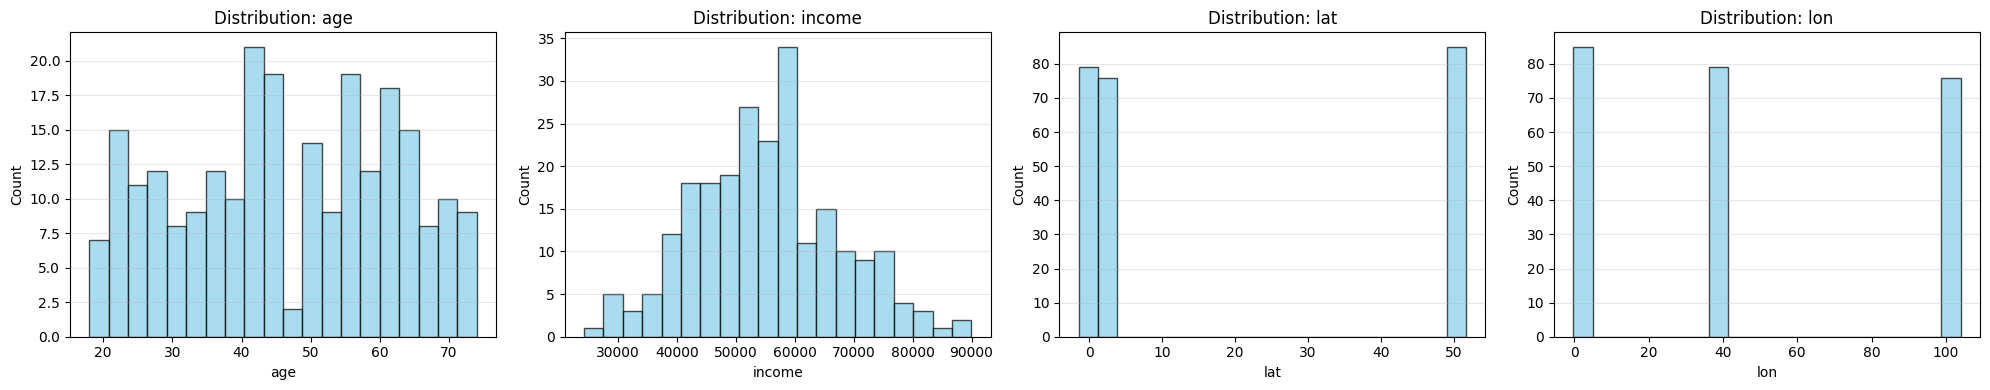

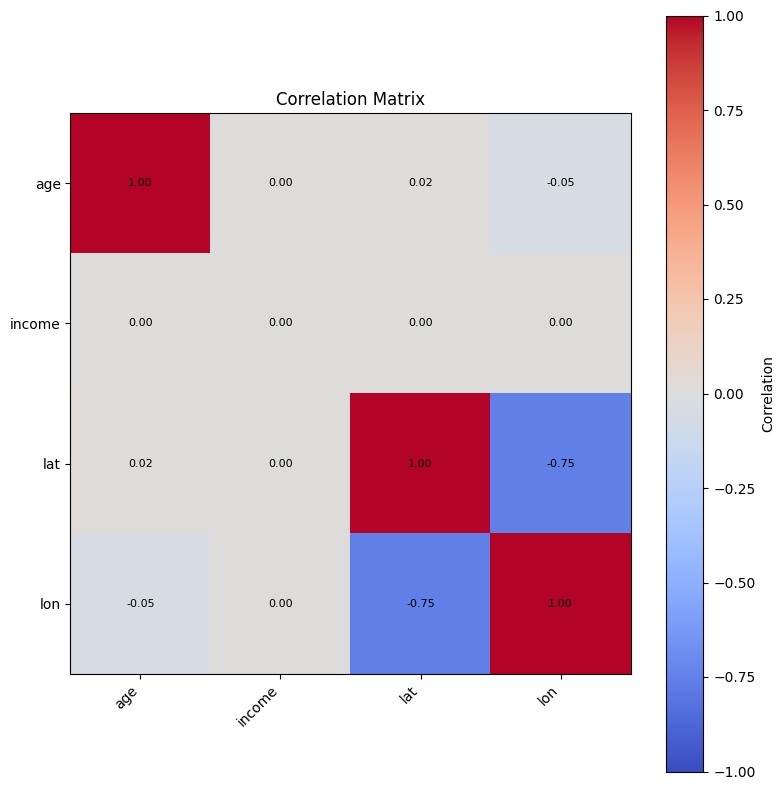

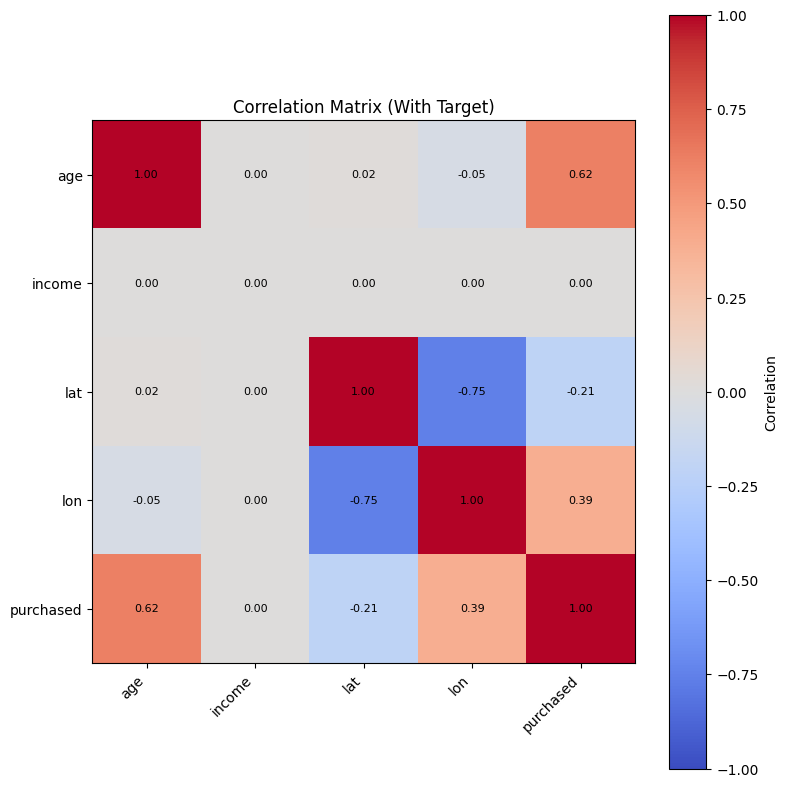

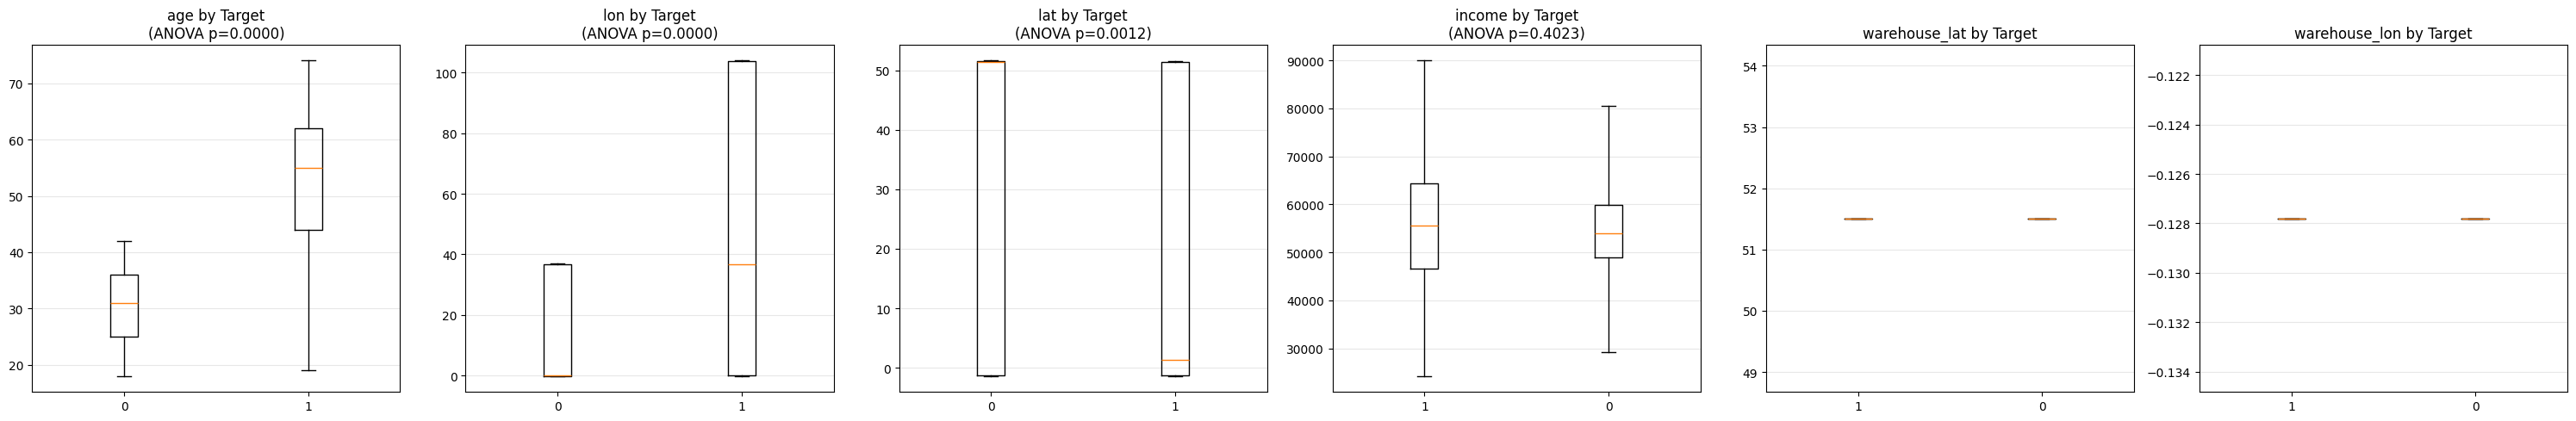

<Figure size 1000x1000 with 0 Axes>

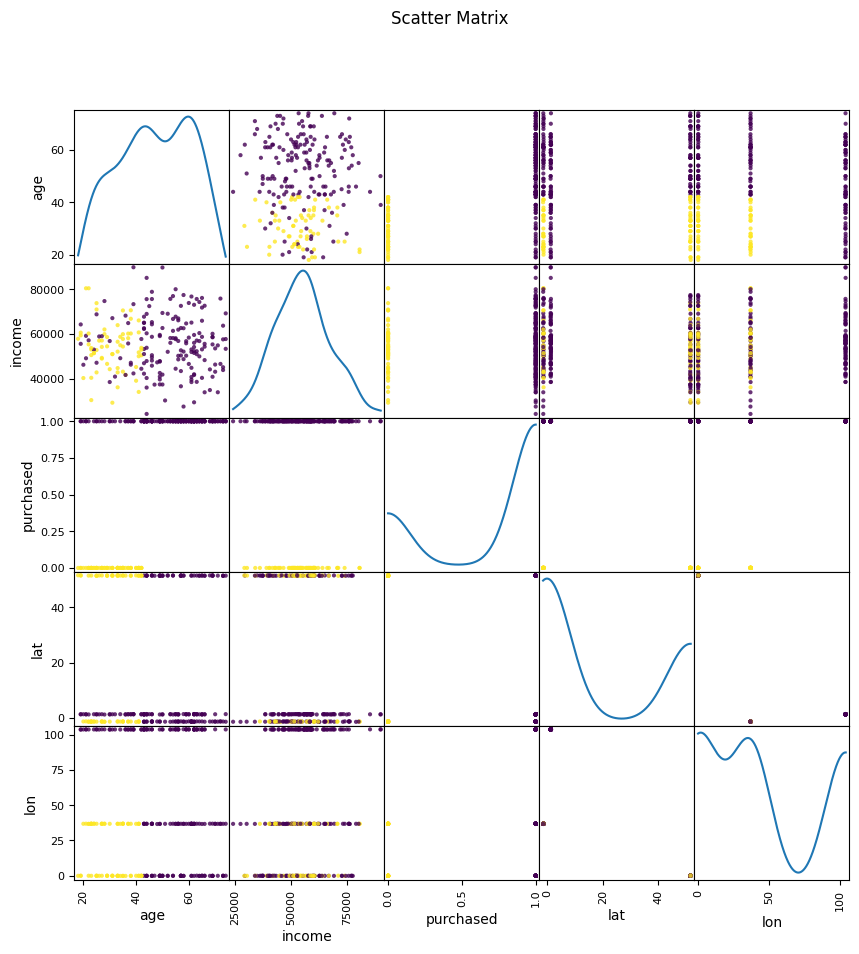

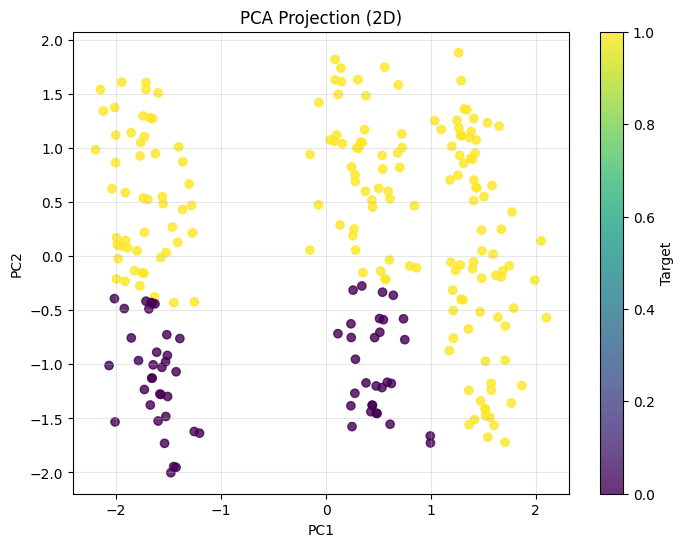

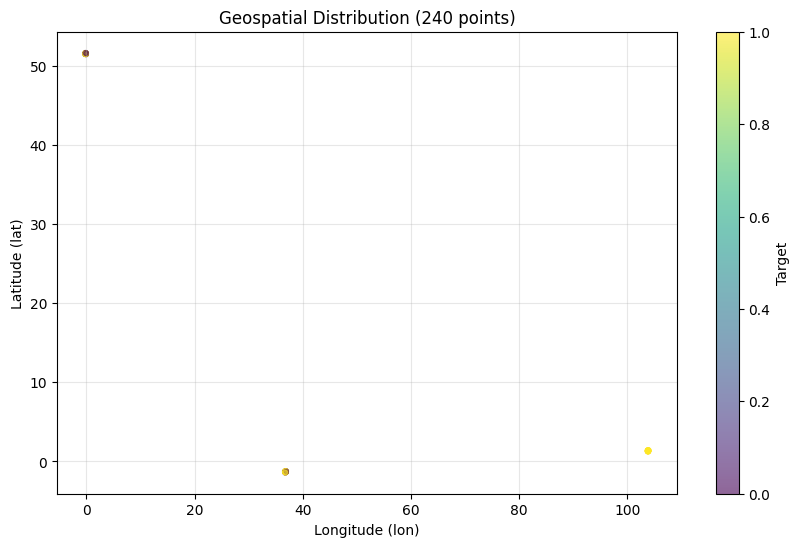

In [10]:
geo_profile = EDAAnalyzer(geo_data).analyze(
    target_col="purchased", lat_col="lat", lon_col="lon"
)
print(f"Geospatial bounds: {geo_profile.geospatial.min_lat:.2f},{geo_profile.geospatial.min_lon:.2f} "
      f"to {geo_profile.geospatial.max_lat:.2f},{geo_profile.geospatial.max_lon:.2f}")
print(f"Centroid: {geo_profile.geospatial.centroid_lat:.2f}, {geo_profile.geospatial.centroid_lon:.2f}")

EDAVisualizer(geo_profile, geo_data).plot()

In [11]:
geo_steps = [
    {
        "name": "distance_to_warehouse",
        "transformer": "GeoDistance",
        "params": {
            "lat1_col": "lat",
            "lon1_col": "lon",
            "lat2_col": "warehouse_lat",
            "lon2_col": "warehouse_lon",
            "method": "haversine",
            "unit": "km",
            "output_column": "distance_to_warehouse_km",
        },
    },
    {
        "name": "h3_cell",
        "transformer": "H3Index",
        "params": {"lat_col": "lat", "lon_col": "lon", "resolution": 5, "output_column": "h3_cell"},
    },
]

geo_transformed, _ = FeatureEngineer(geo_steps).fit_transform(geo_data)
geo_transformed.select("city", "lat", "lon", "distance_to_warehouse_km", "h3_cell").head(8)

city,lat,lon,distance_to_warehouse_km,h3_cell
str,f64,f64,f64,str
"""Singapore""",1.352162,103.79679,10846.295739,"""856520dbfffffff"""
"""Nairobi""",-1.277163,36.85906,6820.795491,"""857a6e43fffffff"""
"""Nairobi""",-1.305807,36.817776,6821.718845,"""857a6e57fffffff"""
"""London""",51.46287,-0.123747,4.959417,"""85194ad3fffffff"""
"""London""",51.484666,-0.142336,2.720779,"""85194ad3fffffff"""
"""London""",51.457818,-0.070072,6.81005,"""85194ad3fffffff"""
"""Singapore""",1.355107,103.818726,10847.521997,"""856520dbfffffff"""
"""London""",51.574411,-0.237821,10.649701,"""85195da7fffffff"""


In [12]:
# Sanity check: London customers should be close to the (London) warehouse;
# Nairobi/Singapore customers should be far. H3 cells should repeat for
# customers close together (same city cluster), giving a compact spatial key.
by_city = geo_transformed.group_by("city").agg(
    pl.col("distance_to_warehouse_km").mean().round(0).alias("avg_distance_km"),
    pl.col("h3_cell").n_unique().alias("unique_h3_cells"),
)
print(by_city.sort("city"))

shape: (3, 3)
┌───────────┬─────────────────┬─────────────────┐
│ city      ┆ avg_distance_km ┆ unique_h3_cells │
│ ---       ┆ ---             ┆ ---             │
│ str       ┆ f64             ┆ u32             │
╞═══════════╪═════════════════╪═════════════════╡
│ London    ┆ 5.0             ┆ 4               │
│ Nairobi   ┆ 6820.0          ┆ 4               │
│ Singapore ┆ 10849.0         ┆ 4               │
└───────────┴─────────────────┴─────────────────┘


## Next steps

- `01_house_prices_regression.ipynb` — regression, deep feature engineering, tuning
- `02_disaster_tweets_text_classification.ipynb` — text/NLP classification
- `03_mall_customers_segmentation.ipynb` — clustering/segmentation
- `04_forest_cover_multiclass_ensemble.ipynb` — multiclass + ensembling
- `05_santander_imbalanced_classification.ipynb` — wide, imbalanced classification
- `06_credit_card_fraud_extreme_imbalance.ipynb` — extreme imbalance, resampling
- `07_spaceship_titanic_classification.ipynb` — end-to-end binary classification
- `08_online_retail_customer_segmentation.ipynb` — RFM feature engineering, clustering/segmentation